No data loaded from ExperimentData_20260416_122309.csv. Skipping this file.


C:\Users\gertv\AppData\Local\Temp\ipykernel_17372\1921683759.py:20: UserWarning: genfromtxt: Empty input file: "Ctrl_Experiment_Data\ExperimentData_20260416_122309.csv"
  raw_data = np.genfromtxt(file_path, delimiter=',', skip_header=1)  # Skip header if present


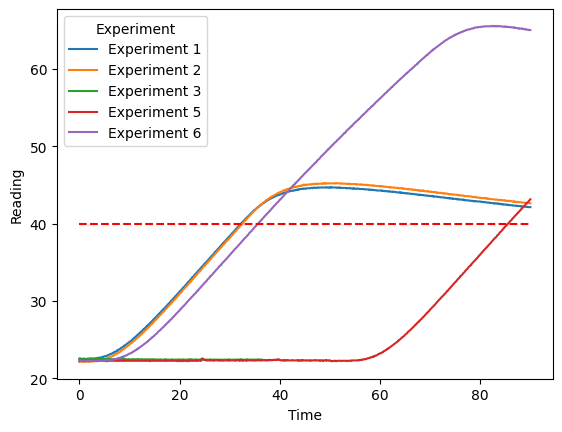

In [112]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
T_ref = 40.0
data_folder = 'Ctrl_Experiment_Data'
folder_contents = sorted([f for f in os.listdir(data_folder) if f.endswith('.csv')])

# Define your signal names (adjust to match your actual data)
signal_names = ['Temp_1', 'Temp_2', 'U_heater', 'U_fan', 'U_vane']

all_data_frames = []

for file_name in folder_contents:
    file_path = os.path.join(data_folder, file_name)
    
    # 1. Load the 2D array (Rows x Columns)
    # Assuming Column 0 is Time, Columns 1-5 are Signals
    raw_data = np.genfromtxt(file_path, delimiter=',', skip_header=1)  # Skip header if present
    
    # Check if data was loaded successfully, some empty CSV files might cause issues
    if raw_data.size == 0:
        print(f"No data loaded from {file_name}. Skipping this file.")
        continue  # Skip to the next file if no data is loaded

    # 2. Create a temporary DataFrame for THIS experiment
    # We create a "Wide" version first
    temp_df = pd.DataFrame(raw_data, columns=['Time'] + signal_names)
    
    # 3. Add a column to identify the experiment
    temp_df['Experiment'] =     f"Experiment {folder_contents.index(file_name) + 1}"  # Extract experiment name from file name
    
    # 4. Transform from "Wide" to "Long" format
    # This turns 5 signal columns into two columns: 'Signal_Type' and 'Value'
    long_df = temp_df.melt(
        id_vars=['Experiment', 'Time'], 
        value_vars=signal_names,
        var_name='Signal_Type', 
        value_name='Reading'
    )
    
    all_data_frames.append(long_df)

# 5. Combine everything into one master DataFrame
final_df = pd.concat(all_data_frames, ignore_index=True)

sns.lineplot(data=final_df[final_df['Signal_Type'] == 'Temp_1'], x='Time', y='Reading', hue='Experiment')
plt.hlines(y=T_ref, xmin = 0, xmax = final_df['Time'].max(), color='red', linestyle='--', label='Setpoint')

In [116]:
def rms(np_array):
    if np_array.size == 0:
        return np.nan  # Return NaN if the array is empty to avoid division by zero
    return np.sqrt(np.mean(np_array**2))

for i in range(1, 6):
    exp_data_i = final_df[(final_df['Signal_Type'] == 'Temp_1') & (final_df['Experiment'] == f'Experiment {i}')]['Reading'].to_numpy()
    error = exp_data_i - T_ref
    print(f"RMS Error for Experiment {i}: {rms(error)}")

RMS Error for Experiment 1: 7.796762286633665
RMS Error for Experiment 2: 8.10697145040423
RMS Error for Experiment 3: 17.57140374835406
RMS Error for Experiment 4: nan
RMS Error for Experiment 5: 15.441166793026934
